In [1]:
# Import all the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


##  Part A — Dataset Preparation

In [2]:
# Load the dataset (already uploaded to this Colab session)
df = pd.read_csv("heart.csv")

print("Shape:", df.shape)
df.head()


Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [81]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [82]:
# Check for missing values
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [83]:
# Feature Engineering
if "age" in df.columns:
    df["age_group"] = pd.cut(df["age"], bins=[0, 40, 55, 70, 100],
                              labels=["<40", "40-55", "55-70", "70+"])

if "chol" in df.columns:
    df["high_cholesterol"] = (df["chol"] > 240).astype(int)

print("New engineered features added: 'age_group', 'high_cholesterol'")
df.head()


New engineered features added: 'age_group', 'high_cholesterol'


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,high_cholesterol
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,40-55,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,40-55,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,55-70,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,55-70,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,55-70,1


In [84]:
# Check and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate rows: 723


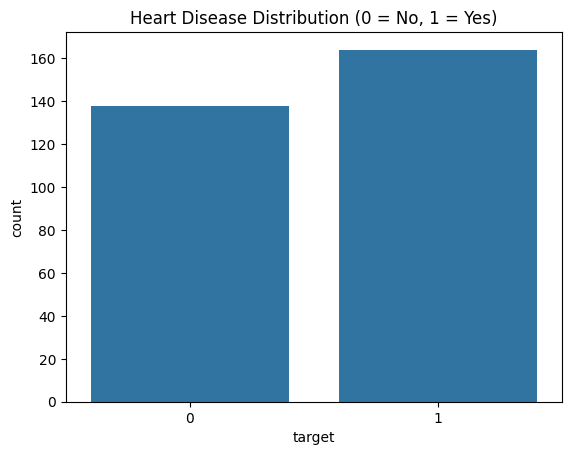

In [85]:
# Quick EDA - target distribution
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()


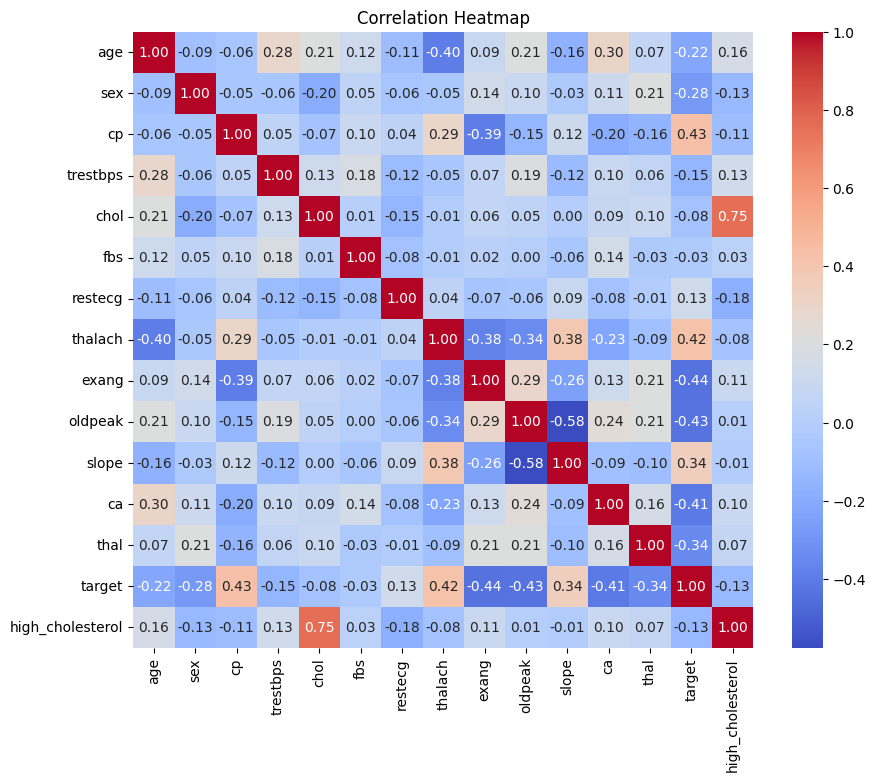

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quick EDA - correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##  Part B — Model Development

In [87]:
# Split features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

# One-hot encode the 'age_group' column
X = pd.get_dummies(X, columns=['age_group'], drop_first=True, dtype=int)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (helps Logistic Regression perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (241, 17)  Test size: (61, 17)


In [88]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)


In [89]:
# Train Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)


In [90]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


## Part C — Model Evaluation

In [91]:
# Compare all three models using accuracy, precision, recall, and F1-score
results = {
    "Logistic Regression": log_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

metrics_data = []
for name, pred in results.items():
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    metrics_data.append([name, accuracy, precision, recall, f1])

    print(f"--- {name} ---")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print()


results_df = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
display(results_df.sort_values('Accuracy',ascending=False))

best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_name = best_model_row['Model']
print("Best Model:",best_name)

--- Logistic Regression ---
Accuracy : 0.8032786885245902
Precision: 0.7428571428571429
Recall   : 0.896551724137931
F1 Score : 0.8125

--- Decision Tree ---
Accuracy : 0.6885245901639344
Precision: 0.6923076923076923
Recall   : 0.6206896551724138
F1 Score : 0.6545454545454545

--- Random Forest ---
Accuracy : 0.819672131147541
Precision: 0.78125
Recall   : 0.8620689655172413
F1 Score : 0.819672131147541



,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.819672,0.781250,0.862069,0.819672
0,Logistic Regression,0.803279,0.742857,0.896552,0.812500
1,Decision Tree,0.688525,0.692308,0.620690,0.654545


Best Model: Random Forest


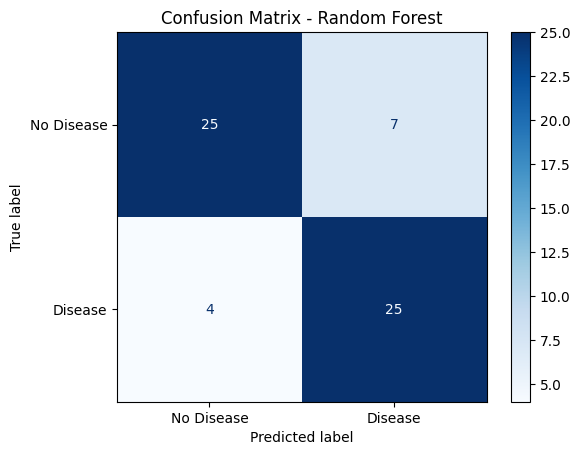

In [92]:
# Confusion matrix for the best model (Random Forest, usually performs best)
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()
